## 1) Load Libraries & Dataset

### Load Important Libraries

Run in Bash:

`python -m pip install -r requirements.txt`

Make sure the python version is 3.11 or above

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

import tensorflow as tf
import matplotlib.pyplot as plt
from spektral.layers import GCNConv, GATConv

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report, average_precision_score, confusion_matrix

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Dropout, Multiply, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### Load Dataset

In [3]:
df = pd.read_csv('dataset_hiv.csv')
df.head()

,smiles,activity,HIV_active
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0


## 2) Exploratory Data Analysis

### Check Missing Values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41127 entries, 0 to 41126
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   smiles      41127 non-null  object
 1   activity    41127 non-null  object
 2   HIV_active  41127 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 964.0+ KB


There are no missing values.

In [5]:
def count_atoms(smiles):
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return np.nan
    return molecule.GetNumAtoms()

df["num_atoms"] = df["smiles"].apply(count_atoms)

print(df["num_atoms"].describe(), "\n")
print(df["num_atoms"].quantile([0.90, 0.95, 0.99, 1.00]), "\n")
print("Invalid SMILES:", df["num_atoms"].isna().sum())

[21:09:38] WARNING: not removing hydrogen atom without neighbors
[21:09:38] WARNING: not removing hydrogen atom without neighbors


count    41127.000000
mean        25.510322
std         12.112792
min          2.000000
25%         18.000000
50%         23.000000
75%         29.000000
max        222.000000
Name: num_atoms, dtype: float64 

0.90     38.0
0.95     46.0
0.99     70.0
1.00    222.0
Name: num_atoms, dtype: float64 

Invalid SMILES: 0


The above code counts the number of atoms in each molecule represented by each SMILES string, and then summarizes the distribution. From the distribution result, only about 1% of the molecules have more than 70 atoms. The jump from 70 at the 99th percentile to a maximum of 222 suggests that the dataset have a relatively small number of very large molecules. We will exclude data at the top 3% percentile due to computing power limitation.

In [6]:
# Exclude smile top 3% due to limited computing power
max_num_atoms = 60
df_filtered = df[df["num_atoms"] <= max_num_atoms].reset_index(drop=True).copy()
df_filtered['HIV_active'].value_counts()

HIV_active
0    39065
1     1319
Name: count, dtype: int64

The classes are highly imbalance (only around 3% for class 1)

## 3) Data Preprocessing

### Split Data into Training and Validation Set

In [7]:
# Split the dataset into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(df_filtered['smiles'], df_filtered['HIV_active'], test_size=0.2, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered["smiles"],
    df_filtered["HIV_active"],
    test_size=0.2,
    random_state=1,
    stratify=df_filtered["HIV_active"]
)

# Split the training partition into model-fit and validation sets now so duplicated minority samples created by RandomOverSampler cannot leak into validation.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Create a dataframe of the model-fit set only
data_train = pd.DataFrame({'smiles': X_fit, 'HIV_active': y_fit})


### Balancing Classes

In [8]:
# ---------------------------------------------------------
# Use the ORIGINAL model-fit data.
# No oversampling and no undersampling.
# Class imbalance will be handled using class weights.
# ---------------------------------------------------------

data = X_fit.to_frame(name="smiles")

print("Training class distribution:")
print(y_fit.value_counts())

print("\nTraining class proportion:")
print(y_fit.value_counts(normalize=True))

Training class distribution:
HIV_active
0    25001
1      844
Name: count, dtype: int64

Training class proportion:
HIV_active
0    0.967344
1    0.032656
Name: proportion, dtype: float64


The original model-fit training set is retained without over- or undersampling. Class imbalance is handled using class weighting during model training. Validation and test sets retain their original class distribution.

### Feature Extraction: Atom-Centered Morgan Fingerprint

Each atom is represented by the Morgan fingerprint bits generated by environments **centered on that atom**.

In [9]:
# ----------------------------------------------------
# 1. Determine atom-centered Morgan features per atom
# ----------------------------------------------------

# Radius 2 corresponds to local environments up to two bonds from each center atom.
# 256 bits is used as a compact node representation for the current dense/padded pipeline.
MORGAN_RADIUS = 1
MORGAN_NBITS = 256
NUM_ATOM_FEATURES = MORGAN_NBITS

# Chirality and bond types are included because they can carry chemically relevant information.
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=MORGAN_RADIUS,
    fpSize=MORGAN_NBITS,
    includeChirality=True,
    useBondTypes=True,
    includeRingMembership=True
)


def atom_centered_morgan_features(molecule):
    """
    Menghasilkan feature matrix Morgan berbasis atom.
    Setiap row merepresentasikan satu atom. Bit bernilai 1 jika bit Morgan tersebut dihasilkan oleh environment yang berpusat pada atom tersebut.
    Output shape: (num_atoms, MORGAN_NBITS)
    """
    num_atoms = molecule.GetNumAtoms()

    additional_output = rdFingerprintGenerator.AdditionalOutput()
    additional_output.AllocateAtomToBits()

    # Fingerprint molekul dihitung sekali, atomToBits memberi bit yang pusat Morgan environment-nya adalah masing-masing atom.
    morgan_generator.GetFingerprint(molecule, additionalOutput=additional_output)
    atom_to_bits = additional_output.GetAtomToBits()

    # Binary node features. uint8 reduces memory usage in the padded dataset.
    feature_matrix = np.zeros((num_atoms, MORGAN_NBITS), dtype=np.uint8)

    for atom_idx, bits in enumerate(atom_to_bits):
        if bits:
            feature_matrix[atom_idx, list(bits)] = 1

    return feature_matrix


In [10]:
# ------------------------------------------------------
# 2. Function to convert a SMILES string into GCN input
# ------------------------------------------------------

def smiles_to_padded_graph(smiles, max_num_atoms):
    """
    Mengubah satu SMILES menjadi:
    - X: padded atom-centered Morgan feature matrix
    - A: padded and normalized adjacency matrix
    - M: atom mask
    - num_atoms: jumlah atom asli
    """

    molecule = Chem.MolFromSmiles(smiles)

    if molecule is None:
        raise ValueError(f"SMILES tidak valid: {smiles}")

    num_atoms = molecule.GetNumAtoms()

    if num_atoms > max_num_atoms:
        raise ValueError(
            f"Molekul memiliki {num_atoms} atom, "
            f"lebih besar dari max_num_atoms={max_num_atoms}"
        )

    # Atom-centered Morgan feature matrix untuk atom asli
    atom_feature_matrix = atom_centered_morgan_features(molecule)

    # Adjacency matrix untuk atom asli
    adjacency_matrix = Chem.GetAdjacencyMatrix(molecule).astype(np.float32)

    # Menambahkan self-loop dan normalisasi pada Adjacency matrix
    adjacency_matrix = GCNConv.preprocess(adjacency_matrix).astype(np.float32)

    # Membuat padded feature matrix
    X = np.zeros((max_num_atoms, NUM_ATOM_FEATURES), dtype=np.uint8)
    X[:num_atoms, :] = atom_feature_matrix

    # Membuat padded adjacency matrix
    A = np.zeros((max_num_atoms, max_num_atoms), dtype=np.float32)
    A[:num_atoms, :num_atoms] = adjacency_matrix

    # Atom mask
    M = np.zeros((max_num_atoms, 1), dtype=np.float32)
    M[:num_atoms, 0] = 1.0

    return X, A, M, num_atoms

# Example usage for 1 smile string:
# X, A, M, num_atoms = smiles_to_padded_graph(smiles="CCO", max_num_atoms=5)


In [11]:
# ---------------------------------------------------------------
# 3. Apply function to all strings, determine max number of atoms
# ---------------------------------------------------------------

data["num_atoms"] = data["smiles"].apply(count_atoms)
max_num_atoms = data["num_atoms"].max()
print("Maximum atoms:", max_num_atoms)

Maximum atoms: 60


In [12]:
# -------------------------------------------------
# 4. Convert the entire DataFrame into input array
# -------------------------------------------------

def dataframe_to_gcn_inputs(dataframe, smiles_column, max_num_atoms):
    """
    Mengubah seluruh kolom SMILES menjadi array input GCN.

    Mengembalikan:
    - X_all
    - A_all
    - M_all
    - valid_indices
    - failed_rows
    """

    X_list = []
    A_list = []
    M_list = []

    valid_indices = []
    failed_rows = []

    for index, smiles in dataframe[smiles_column].items():

        try:
            X, A, M, num_atoms = smiles_to_padded_graph(smiles=smiles, max_num_atoms=max_num_atoms)

            X_list.append(X)
            A_list.append(A)
            M_list.append(M)

            valid_indices.append(index)

        except (ValueError, TypeError) as error:
            failed_rows.append({
                "index": index,
                "smiles": smiles,
                "error": str(error)
            })

    if len(X_list) == 0:
        raise ValueError("Tidak ada SMILES yang berhasil dikonversi.")

    X_all = np.stack(X_list).astype(np.uint8)
    A_all = np.stack(A_list).astype(np.float32)
    M_all = np.stack(M_list).astype(np.float32)

    return X_all, A_all, M_all, valid_indices, failed_rows

In [13]:
# Apply function on train data
X_graph_train, A_graph_train, M_graph_train, valid_indices_train, failed_rows_train = (
    dataframe_to_gcn_inputs(dataframe=data, smiles_column="smiles", max_num_atoms=max_num_atoms)
)
print("X:", X_graph_train.shape)
print("A:", A_graph_train.shape)
print("M:", M_graph_train.shape)
print("Valid molecules:", len(valid_indices_train))
print("Failed molecules:", len(failed_rows_train))

# Apply function on validation data
X_val_df = X_val.to_frame(name="smiles")

X_graph_val, A_graph_val, M_graph_val, valid_indices_val, failed_rows_val = (
    dataframe_to_gcn_inputs(dataframe=X_val_df, smiles_column="smiles", max_num_atoms=max_num_atoms)
)

# Apply function on test data
X_test_df = X_test.to_frame(name="smiles")

X_graph_test, A_graph_test, M_graph_test, valid_indices_test, failed_rows_test = (
    dataframe_to_gcn_inputs(dataframe=X_test_df, smiles_column="smiles", max_num_atoms=max_num_atoms)
)


X: (25845, 60, 256)
A: (25845, 60, 60)
M: (25845, 60, 1)
Valid molecules: 25845
Failed molecules: 0


[21:10:23] WARNING: not removing hydrogen atom without neighbors
[21:10:23] WARNING: not removing hydrogen atom without neighbors


In [14]:
# ------------------------------------------------------------
# Match labels with molecules successfully converted to graphs
# ------------------------------------------------------------

y_graph_train = (
    y_fit.loc[valid_indices_train]
    .to_numpy(dtype=np.float32)
    .reshape(-1)
)

y_graph_val = (
    y_val.loc[valid_indices_val]
    .to_numpy(dtype=np.float32)
    .reshape(-1)
)

y_graph_test = (
    y_test.loc[valid_indices_test]
    .to_numpy(dtype=np.float32)
    .reshape(-1)
)


print("Train graph:", X_graph_train.shape[0])
print("Train label:", y_graph_train.shape[0])

print("Validation graph:", X_graph_val.shape[0])
print("Validation label:", y_graph_val.shape[0])

print("Test graph :", X_graph_test.shape[0])
print("Test label :", y_graph_test.shape[0])

# ---------------------------------------------------------
# Calculate balanced class weights from TRAINING DATA ONLY
# ---------------------------------------------------------

classes = np.array([0, 1], dtype=np.int32)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_graph_train.astype(np.int32)
)

class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

print("Class weights:")
print(class_weight)

Train graph: 25845
Train label: 25845
Validation graph: 6462
Validation label: 6462
Test graph : 8077
Test label : 8077
Class weights:
{0: 0.5168793248270069, 1: 15.311018957345972}


In [15]:
y_graph_train = y_graph_train.reshape(-1, 1)
y_graph_val = y_graph_val.reshape(-1, 1)
y_graph_test = y_graph_test.reshape(-1, 1)

print(y_graph_train.shape)
print(y_graph_val.shape)
print(y_graph_test.shape)


(25845, 1)
(6462, 1)
(8077, 1)


## 4) Graph Convolutional Network (GCN)

Input Data:
- X_graph_train
- A_graph_train
- M_graph_train

Label Data:
- y_graph_train

Architecture:
- GCN 64
- GCN 128
- GCN 256
- GCN 512
- masked global average pooling
- Dense sigmoid

### a) Modeling

In [16]:
random.seed(1)
np.random.seed(1)
tf.random.set_seed(1)

In [17]:
max_num_atoms = X_graph_train.shape[1]
num_atom_features = X_graph_train.shape[2]

print("Maximum atoms :", max_num_atoms)
print("Features per atom :", num_atom_features)

Maximum atoms : 60
Features per atom : 256


#### Setting Layers

In [18]:
# Fungsi untuk menghitung atom asli (padding tidak ikut dihitung)

@tf.keras.utils.register_keras_serializable(package="MolecularGCN")
class MaskedGlobalAveragePooling(tf.keras.layers.Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        node_embeddings, atom_mask = inputs

        # Menyamakan dtype mask dengan node embeddings
        atom_mask = tf.cast(atom_mask, node_embeddings.dtype)

        # Menghilangkan embedding node padding
        masked_embeddings = node_embeddings * atom_mask

        # Menjumlahkan embedding seluruh atom asli
        summed_embeddings = tf.reduce_sum(masked_embeddings, axis=1)

        # Menghitung jumlah atom asli setiap molekul
        num_real_atoms = tf.reduce_sum(atom_mask, axis=1)

        # Mencegah pembagian dengan nol
        epsilon = tf.cast(tf.keras.backend.epsilon(), num_real_atoms.dtype)
        num_real_atoms = tf.maximum(num_real_atoms, epsilon)

        # Rata-rata embedding hanya dari atom asli
        return summed_embeddings / num_real_atoms

    def compute_output_shape(self, input_shape):
        node_embedding_shape = input_shape[0]
        return (node_embedding_shape[0], node_embedding_shape[-1])

    def get_config(self):
        config = super().get_config()
        return config

In [19]:
# ------------------------------------------
# Input layers
# ------------------------------------------
X_in = Input(shape=(max_num_atoms, num_atom_features), name="atom_features")
A_in = Input(shape=(max_num_atoms, max_num_atoms), name="adjacency_matrix")
M_in = Input(shape=(max_num_atoms, 1), name="atom_mask")


# ------------------------------------------
# GCN layer 1
# ------------------------------------------
graph_conv1 = GCNConv(channels=64, activation="relu", name="gcn_1")([X_in, A_in])

# Pastikan node padding tetap nol
graph_conv1 = Multiply(name="mask_gcn_1")([graph_conv1, M_in])
graph_conv1 = Dropout(0.20, name="dropout_gcn_1")(graph_conv1)


# ------------------------------------------
# GCN layer 2
# ------------------------------------------
graph_conv2 = GCNConv(channels=128, activation="relu", name="gcn_2")([graph_conv1, A_in])
graph_conv2 = Multiply(name="mask_gcn_2")([graph_conv2, M_in])
graph_conv2 = Dropout(0.20, name="dropout_gcn_2")(graph_conv2)


# ------------------------------------------
# GCN layer 3
# ------------------------------------------
graph_conv3 = GCNConv(channels=256, activation="relu", name="gcn_3")([graph_conv2, A_in])
graph_conv3 = Multiply(name="mask_gcn_3")([graph_conv3, M_in])
graph_conv3 = Dropout(0.25, name="dropout_gcn_3")(graph_conv3)


# ------------------------------------------
# GCN layer 4
# ------------------------------------------
graph_conv4 = GCNConv(channels=512, activation="relu", name="gcn_4")([graph_conv3, A_in])
graph_conv4 = Multiply(name="mask_gcn_4")([graph_conv4, M_in])


# ------------------------------------------
# Global pooling
# ------------------------------------------
pool = MaskedGlobalAveragePooling(name="masked_global_average_pooling")([graph_conv4, M_in])


# ------------------------------------------
# Classification head
# ------------------------------------------
dense = Dense(128, activation="relu", name="dense_1")(pool)
dense = Dropout(0.30, name="dropout_dense")(dense)
output = Dense(1, activation="sigmoid", name="prediction")(dense)


# ------------------------------------------
# Build model
# ------------------------------------------
model_gcn = Model(inputs=[X_in, A_in, M_in], outputs=output, name="molecular_gcn")
model_gcn.summary()


Model: "molecular_gcn"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 atom_features (InputLayer)  [(None, 60, 256)]            0         []                            
                                                                                                  
 adjacency_matrix (InputLay  [(None, 60, 60)]             0         []                            
 er)                                                                                              
                                                                                                  
 gcn_1 (GCNConv)             (None, 60, 64)               16448     ['atom_features[0][0]',       
                                                                     'adjacency_matrix[0][0]']    
                                                                                     

#### Training Model

In [20]:
model_gcn.compile(optimizer=Adam(learning_rate=0.001), 
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                       tf.keras.metrics.AUC(name="auc"),
                       tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
                       tf.keras.metrics.Precision(name="precision"),
                       tf.keras.metrics.Recall(name="recall")
                       ]
             )

callbacks = [EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True, verbose=1),
             ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
             ModelCheckpoint(filepath="model/gcn_weights.weights.h5", monitor="val_pr_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1)
            ]

In [21]:
X_gcn_fit = X_graph_train
A_gcn_fit = A_graph_train
M_gcn_fit = M_graph_train
y_gcn_fit = y_graph_train

X_gcn_val = X_graph_val
A_gcn_val = A_graph_val
M_gcn_val = M_graph_val
y_gcn_val = y_graph_val

# history = model_gcn.fit(x=[X_gcn_fit, A_gcn_fit, M_gcn_fit], y=y_gcn_fit, 
#                     validation_data=([X_gcn_val, A_gcn_val, M_gcn_val], y_gcn_val), 
#                     epochs=50, batch_size=32, shuffle=True, callbacks=callbacks)

history = model_gcn.fit(
    x=[X_gcn_fit, A_gcn_fit, M_gcn_fit], y=y_gcn_fit,
    validation_data=([X_gcn_val, A_gcn_val, M_gcn_val], y_gcn_val),
    epochs=50,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight,
    callbacks=callbacks
)


Epoch 1/50

808/808 [==============================] - ETA: 0s - loss: 0.6210 - accuracy: 0.7825 - auc: 0.6865 - pr_auc: 0.1415 - precision: 0.0745 - recall: 0.4953
Epoch 1: val_pr_auc improved from -inf to 0.20296, saving model to model\gcn_weights.weights.h5
808/808 [==============================] - 78s 88ms/step - loss: 0.6210 - accuracy: 0.7825 - auc: 0.6865 - pr_auc: 0.1415 - precision: 0.0745 - recall: 0.4953 - val_loss: 0.7010 - val_accuracy: 0.7803 - val_auc: 0.7286 - val_pr_auc: 0.2030 - val_precision: 0.0828 - val_recall: 0.5687 - lr: 0.0010
Epoch 2/50
808/808 [==============================] - ETA: 0s - loss: 0.5379 - accuracy: 0.8518 - auc: 0.7795 - pr_auc: 0.2618 - precision: 0.1282 - recall: 0.6102
Epoch 2: val_pr_auc improved from 0.20296 to 0.27090, saving model to model\gcn_weights.weights.h5
808/808 [==============================] - 71s 88ms/step - loss: 0.5379 - accuracy: 0.8518 - auc: 0.7795 - pr_auc: 0.2618 - precision: 0.1282 - recall: 0.6102 - val_loss: 0.4651 

### b) Evaluation

#### Accuracy Graph

In [22]:
test_results = model_gcn.evaluate(x=[X_graph_test, A_graph_test, M_graph_test], y=y_graph_test, batch_size=32, return_dict=True)
test_results

253/253 [==============================] - 10s 40ms/step - loss: 0.3833 - accuracy: 0.8724 - auc: 0.7908 - pr_auc: 0.3004 - precision: 0.1465 - recall: 0.6023


{'loss': 0.38333484530448914,
 'accuracy': 0.8723536133766174,
 'auc': 0.7908208966255188,
 'pr_auc': 0.30038583278656006,
 'precision': 0.14654378592967987,
 'recall': 0.6022727489471436}

#### Classification Report

In [23]:
y_test_probability = model_gcn.predict([X_graph_test, A_graph_test, M_graph_test], batch_size=32).reshape(-1)
y_test_prediction = (y_test_probability >= 0.5).astype(int)
print(classification_report(y_graph_test.reshape(-1), y_test_prediction, digits=4))

253/253 [==============================] - 9s 33ms/step
              precision    recall  f1-score   support

         0.0     0.9850    0.8815    0.9304      7813
         1.0     0.1465    0.6023    0.2357       264

    accuracy                         0.8724      8077
   macro avg     0.5658    0.7419    0.5830      8077
weighted avg     0.9576    0.8724    0.9077      8077



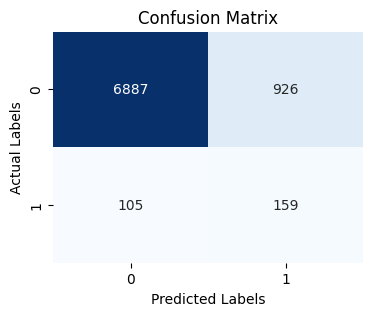

In [24]:
confusion = confusion_matrix(y_graph_test.reshape(-1), y_test_prediction)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

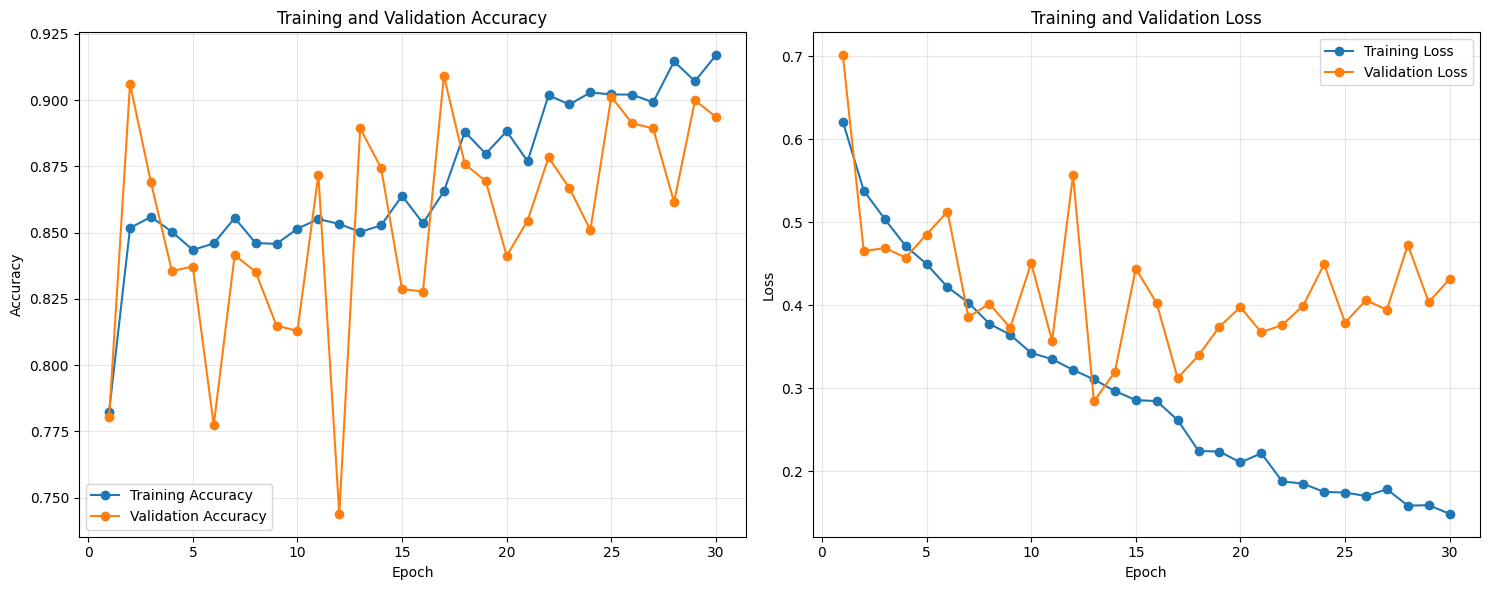

In [25]:
# Jumlah epoch yang benar-benar dijalankan
epochs_range = range(1, len(history.history["loss"]) + 1)

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)


# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### AUC Curve

ROC-AUC: 0.7887497624394463
PR-AUC: 0.29913036730862114


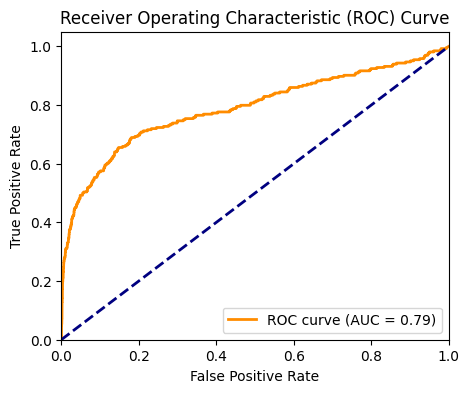

In [26]:
print("ROC-AUC:", roc_auc_score(y_graph_test.reshape(-1), y_test_probability))
print("PR-AUC:", average_precision_score(y_graph_test.reshape(-1), y_test_probability))

# ROC Curve
fpr, tpr, _ = roc_curve(y_graph_test.reshape(-1), y_test_probability)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### c) Save & Load Model

In [27]:
# SAVE MODEL
model_gcn.save("model/gcn_model.keras")

In [28]:
# LOAD MODEL
loaded_model_gcn = tf.keras.models.load_model(
    "model/gcn_model.keras",
    custom_objects={
        "GCNConv": GCNConv,
        "MaskedGlobalAveragePooling":MaskedGlobalAveragePooling,
        "MolecularGCN>MaskedGlobalAveragePooling":MaskedGlobalAveragePooling
    },
    compile=False
)

In [29]:
# APPLY LOADED MODEL TO TEST DATA (or any data)
y_test_probability = loaded_model_gcn.predict([X_graph_test, A_graph_test, M_graph_test], batch_size=32).reshape(-1)
y_test_prediction = (y_test_probability >= 0.5).astype(int)

print("Probabilitas 10 data pertama:")
print(y_test_probability[:10])

print("Prediksi kelas 10 data pertama:")
print(y_test_prediction[:10])

253/253 [==============================] - 8s 32ms/step
Probabilitas 10 data pertama:
[1.2391331e-07 1.0791011e-07 3.2939352e-03 6.0475256e-02 3.9770766e-05
 1.2050316e-12 5.8630276e-01 9.5345342e-01 7.8043598e-01 1.6132820e-01]
Prediksi kelas 10 data pertama:
[0 0 0 0 0 0 1 1 1 0]


## 5) Graph Attention Network (GAT)

Input Data:
- X_graph_train
- A_graph_train
- M_graph_train

Label Data:
- y_graph_train

Architecture:
- GAT layer 1: 3 heads × 64 channels
- GAT layer 2: 3 heads × 64 channels
- GAT layer 3: 3 heads × 64 channels
- Masked global average pooling
- Dense 128 ReLU
- Dense 1 sigmoid

### a) Modeling

In [30]:
# ------------------------------------------
# Mengubah adjacency matrix yang awalnya normalized menjadi binary adjacency untuk GAT
# ------------------------------------------

X_graph_train = np.asarray(X_graph_train, dtype=np.uint8)
X_graph_val = np.asarray(X_graph_val, dtype=np.uint8)
X_graph_test = np.asarray(X_graph_test, dtype=np.uint8)

M_graph_train = np.asarray(M_graph_train, dtype=np.float32)
M_graph_val = np.asarray(M_graph_val, dtype=np.float32)
M_graph_test = np.asarray(M_graph_test, dtype=np.float32)


# Semua nilai nonzero dianggap sebagai edge
A_gat_train = (np.asarray(A_graph_train) > 0).astype(np.float32)
A_gat_val = (np.asarray(A_graph_val) > 0).astype(np.float32)
A_gat_test = (np.asarray(A_graph_test) > 0).astype(np.float32)


# Membuat mask pasangan node: edge hanya boleh ada jika kedua node merupakan atom asli
valid_pairs_train = (M_graph_train * np.transpose(M_graph_train, (0, 2, 1)))
valid_pairs_val = (M_graph_val * np.transpose(M_graph_val, (0, 2, 1)))
valid_pairs_test = (M_graph_test * np.transpose(M_graph_test, (0, 2, 1)))


# Menghilangkan kemungkinan edge yang melibatkan node padding
A_gat_train = A_gat_train * valid_pairs_train
A_gat_val = A_gat_val * valid_pairs_val
A_gat_test = A_gat_test * valid_pairs_test


print("X train :", X_graph_train.shape)
print("A train :", A_gat_train.shape)
print("M train :", M_graph_train.shape)

print("Nilai adjacency GAT:")
print(np.unique(A_gat_train))


X train : (25845, 60, 256)
A train : (25845, 60, 60)
M train : (25845, 60, 1)
Nilai adjacency GAT:
[0. 1.]


#### Setting Layers

In [31]:
@tf.keras.utils.register_keras_serializable(package="MolecularGAT")
class MaskedGlobalAveragePooling(tf.keras.layers.Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        node_embeddings, atom_mask = inputs

        # Menyamakan dtype mask dengan node embeddings
        atom_mask = tf.cast(atom_mask, node_embeddings.dtype)

        # Menghilangkan embedding node padding
        masked_embeddings = node_embeddings * atom_mask

        # Menjumlahkan embedding seluruh atom asli
        summed_embeddings = tf.reduce_sum(masked_embeddings, axis=1)

        # Menghitung jumlah atom asli setiap molekul
        num_real_atoms = tf.reduce_sum(atom_mask, axis=1)

        # Mencegah pembagian dengan nol
        epsilon = tf.cast(tf.keras.backend.epsilon(), num_real_atoms.dtype)
        num_real_atoms = tf.maximum(num_real_atoms, epsilon)

        # Rata-rata embedding dari atom asli
        return summed_embeddings / num_real_atoms

    def compute_output_shape(self, input_shape):
        node_embedding_shape = input_shape[0]
        return (node_embedding_shape[0], node_embedding_shape[-1])

    def get_config(self):
        config = super().get_config()
        return config

In [ ]:
# ------------------------------------------
# Input layers
# ------------------------------------------
X_in = tf.keras.Input(shape=(max_num_atoms, num_atom_features), name="atom_features")
A_in = tf.keras.Input(shape=(max_num_atoms, max_num_atoms), name="adjacency_matrix")
M_in = tf.keras.Input(shape=(max_num_atoms, 1), name="atom_mask")


# ------------------------------------------
# GAT layer 1
# ------------------------------------------
gat_1 = GATConv(channels=64, attn_heads=3, concat_heads=True, dropout_rate=0.20, add_self_loops=True, activation="elu", name="gat_1")([X_in, A_in])

# Memastikan embedding node padding tetap nol
gat_1 = tf.keras.layers.Multiply(name="mask_gat_1")([gat_1, M_in])
gat_1 = tf.keras.layers.Dropout(0.20, name="dropout_gat_1")(gat_1)


# ------------------------------------------
# GAT layer 2
# ------------------------------------------
gat_2 = GATConv(channels=64, attn_heads=3, concat_heads=True, dropout_rate=0.20, add_self_loops=True, activation="elu", name="gat_2")([gat_1, A_in])
gat_2 = tf.keras.layers.Multiply(name="mask_gat_2")([gat_2, M_in])
gat_2 = tf.keras.layers.Dropout(0.20, name="dropout_gat_2")(gat_2)


# ------------------------------------------
# GAT layer 3
# ------------------------------------------
gat_3 = GATConv(channels=64, attn_heads=3, concat_heads=True, dropout_rate=0.20, add_self_loops=True, activation="elu", name="gat_3")([gat_2, A_in])
gat_3 = tf.keras.layers.Multiply( name="mask_gat_3")([gat_3, M_in])
gat_3 = tf.keras.layers.Dropout( 0.25, name="dropout_gat_3")(gat_3)


# ------------------------------------------
# Global pooling
# ------------------------------------------
pool = MaskedGlobalAveragePooling( name="masked_global_average_pooling")([gat_3, M_in])


# ------------------------------------------
# Classification head
# ------------------------------------------
dense = tf.keras.layers.Dense(128, activation="relu", name="dense_1")(pool)
dense = tf.keras.layers.Dropout(0.30, name="dropout_dense")(dense)
output = tf.keras.layers.Dense(1, activation="sigmoid", name="prediction")(dense)


# ------------------------------------------
# Build model
# ------------------------------------------
model_gat = tf.keras.Model(inputs=[ X_in, A_in, M_in ], outputs=output, name="molecular_gat")
model_gat.summary()

c:\Users\ASUS\anaconda3\envs\hiv_env\Lib\site-packages\tf_keras\src\initializers\initializers.py:121: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model: "molecular_gat"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 atom_features (InputLayer)  [(None, 60, 256)]            0         []                            
                                                                                                  
 adjacency_matrix (InputLay  [(None, 60, 60)]             0         []                            
 er)                                                                                              
                                                                                                  
 gat_1 (GATConv)             (None, 60, 192)              49728     ['atom_features[0][0]',       
                                                                     'adjacency_matrix[0][0]']    
                                                                                      

#### Training Model

In [33]:
model_gat.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                       tf.keras.metrics.AUC(name="auc"),
                       tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
                       tf.keras.metrics.Precision(name="precision"),
                       tf.keras.metrics.Recall(name="recall")
                       ]
              )

callbacks = [EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True, verbose=1),
             ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
             ModelCheckpoint(filepath="model/gat_weights.weights.h5", monitor="val_pr_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1)
            ]

In [34]:
X_gat_fit = X_graph_train
A_gat_fit = A_gat_train
M_gat_fit = M_graph_train
y_gat_fit = y_graph_train

X_gat_val = X_graph_val
M_gat_val = M_graph_val
y_gat_val = y_graph_val

# history = model_gat.fit(x=[X_gat_fit, A_gat_fit, M_gat_fit], y=y_gat_fit,
#                         validation_data=([X_gat_val, A_gat_val, M_gat_val], y_gat_val),
#                         epochs=50, batch_size=32, shuffle=True, callbacks=callbacks)

history = model_gat.fit(
    x=[X_gat_fit, A_gat_fit, M_gat_fit], y=y_gat_fit,
    validation_data=([X_gat_val, A_gat_val, M_gat_val], y_gat_val),
    epochs=50,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/50
808/808 [==============================] - ETA: 0s - loss: 0.6292 - accuracy: 0.7624 - auc: 0.6811 - pr_auc: 0.1238 - precision: 0.0698 - recall: 0.5095
Epoch 1: val_pr_auc improved from -inf to 0.15479, saving model to model\gat_weights.weights.h5
808/808 [==============================] - 156s 186ms/step - loss: 0.6292 - accuracy: 0.7624 - auc: 0.6811 - pr_auc: 0.1238 - precision: 0.0698 - recall: 0.5095 - val_loss: 0.7249 - val_accuracy: 0.7507 - val_auc: 0.7318 - val_pr_auc: 0.1548 - val_precision: 0.0737 - val_recall: 0.5735 - lr: 0.0010
Epoch 2/50
808/808 [==============================] - ETA: 0s - loss: 0.5751 - accuracy: 0.8503 - auc: 0.7491 - pr_auc: 0.1860 - precision: 0.1168 - recall: 0.5462
Epoch 2: val_pr_auc improved from 0.15479 to 0.17385, saving model to model\gat_weights.weights.h5
808/808 [==============================] - 114s 141ms/step - loss: 0.5751 - accuracy: 0.8503 - auc: 0.7491 - pr_auc: 0.1860 - precision: 0.1168 - recall: 0.5462 - val_loss: 0.47

### b) Evaluation

#### Accuracy Graph

In [35]:
test_results = model_gat.evaluate(x=[X_graph_test, A_gat_test, M_graph_test], y=y_graph_test, batch_size=32, return_dict=True)
test_results

253/253 [==============================] - 6s 25ms/step - loss: 0.2775 - accuracy: 0.8818 - auc: 0.7961 - pr_auc: 0.2935 - precision: 0.1442 - recall: 0.5303


{'loss': 0.277530312538147,
 'accuracy': 0.8817630410194397,
 'auc': 0.796144425868988,
 'pr_auc': 0.2934798002243042,
 'precision': 0.1441812515258789,
 'recall': 0.5303030014038086}

#### Classification Report

In [36]:
y_test_probability = model_gat.predict([X_graph_test, A_gat_test, M_graph_test], batch_size=32).reshape(-1)
y_test_prediction = (y_test_probability >= 0.5).astype(int)
print(classification_report(y_graph_test.reshape(-1), y_test_prediction, digits=4))

253/253 [==============================] - 7s 26ms/step
              precision    recall  f1-score   support

         0.0     0.9825    0.8936    0.9360      7813
         1.0     0.1442    0.5303    0.2267       264

    accuracy                         0.8818      8077
   macro avg     0.5634    0.7120    0.5814      8077
weighted avg     0.9551    0.8818    0.9128      8077



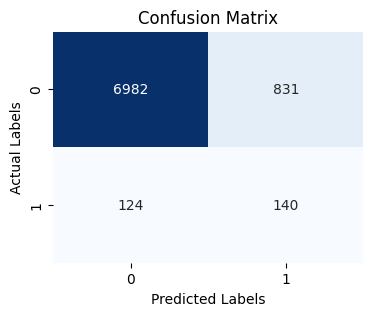

In [37]:
confusion = confusion_matrix(y_graph_test.reshape(-1), y_test_prediction)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

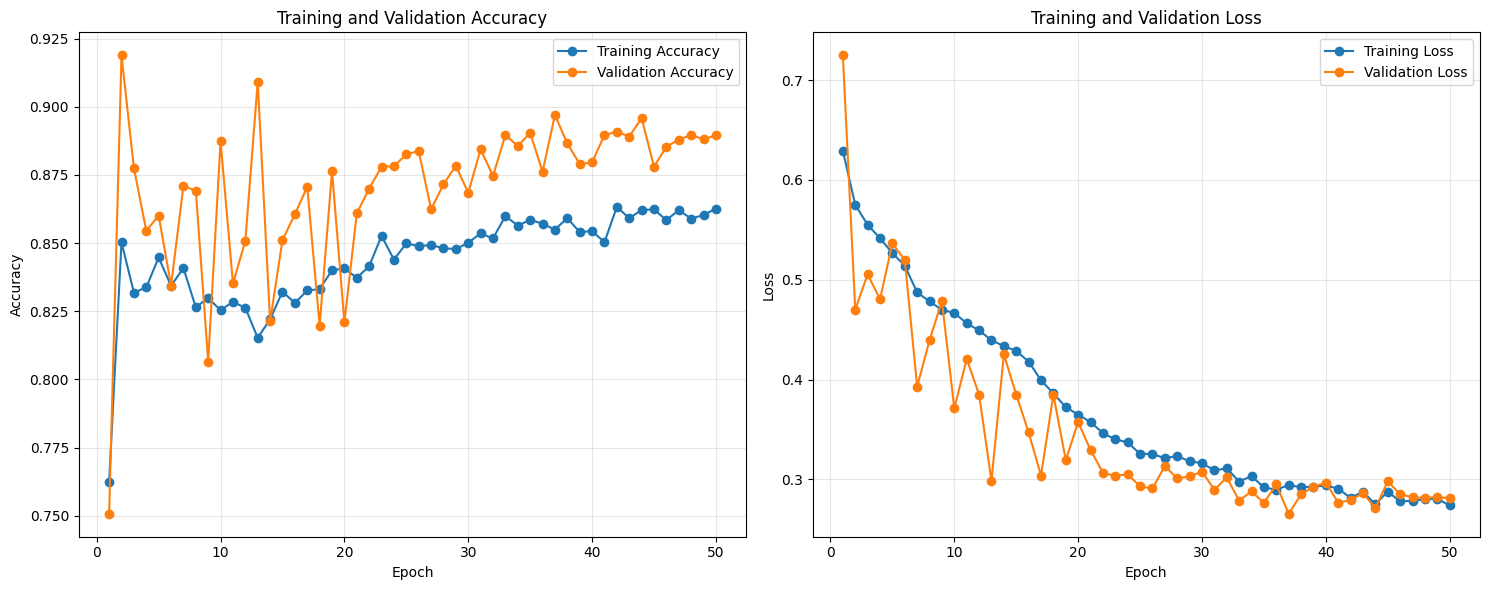

In [38]:
# Jumlah epoch yang benar-benar dijalankan
epochs_range = range(1, len(history.history["loss"]) + 1)

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)


# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### AUC Curve

ROC-AUC: 0.7965880486679157
PR-AUC: 0.2980459377473673


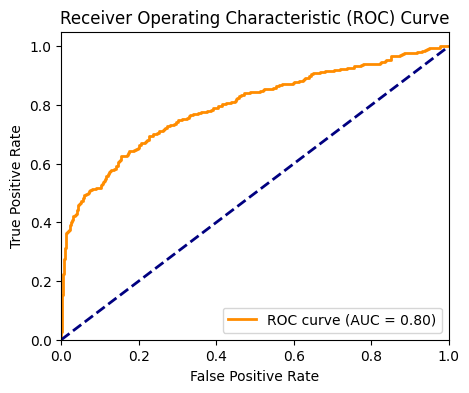

In [39]:
print("ROC-AUC:", roc_auc_score(y_graph_test.reshape(-1), y_test_probability))
print("PR-AUC:", average_precision_score(y_graph_test.reshape(-1), y_test_probability))

# ROC Curve
fpr, tpr, _ = roc_curve(y_graph_test.reshape(-1), y_test_probability)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### c) Save & Load Model

In [40]:
# SAVE MODEL
model_gat.save("model/gat_model.keras")

In [41]:
# LOAD MODEL
loaded_model_gat = tf.keras.models.load_model(
    "model/gat_model.keras",
    custom_objects={
        "GATConv":GATConv,
        "MaskedGlobalAveragePooling":MaskedGlobalAveragePooling,
        "MolecularGAT>MaskedGlobalAveragePooling":MaskedGlobalAveragePooling
    },
    compile=False
)

c:\Users\ASUS\anaconda3\envs\hiv_env\Lib\site-packages\tf_keras\src\initializers\initializers.py:121: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [42]:
# APPLY LOADED MODEL TO TEST DATA (or any data)
y_test_probability = loaded_model_gat.predict([X_graph_test, A_gat_test, M_graph_test], batch_size=32).reshape(-1)
y_test_prediction = (y_test_probability >= 0.5).astype(int)

print("Probabilitas 10 data pertama:")
print(y_test_probability[:10])

print("Prediksi kelas 10 data pertama:")
print(y_test_prediction[:10])

253/253 [==============================] - 9s 33ms/step
Probabilitas 10 data pertama:
[0.05211284 0.00254646 0.55586946 0.44277516 0.02959287 0.01291938
 0.3946008  0.7480526  0.9108415  0.04874749]
Prediksi kelas 10 data pertama:
[0 0 1 0 0 0 0 1 1 0]


## 6) GCN & GAT Feature Fusion

Input Data:
- X_graph_train
- A_graph_train
- A_gat_train
- M_graph_train

Label Data:
- y_graph_train

Arsitektur:

```
                      ┌─ GCN branch ─ pooling ─ GCN feature ─┐
Atom features ────────┤                                      ├─ concatenate ─ Dense 128 ─ sigmoid
                      └─ GAT branch ─ pooling ─ GAT feature ─┘
```

### a) Modeling

#### Setting Layers

In [43]:
@tf.keras.utils.register_keras_serializable(package="MolecularGCNGAT")
class MaskedGlobalAveragePooling(tf.keras.layers.Layer):

    def call(self, inputs):
        node_embeddings, atom_mask = inputs

        # Menyamakan dtype mask dengan node embeddings
        atom_mask = tf.cast(atom_mask, node_embeddings.dtype)

        # Menghilangkan embedding node padding
        masked_embeddings = node_embeddings * atom_mask

        # Menjumlahkan embedding atom asli
        summed_embeddings = tf.reduce_sum(masked_embeddings, axis=1)

        # Menghitung jumlah atom asli
        num_real_atoms = tf.reduce_sum(atom_mask, axis=1)

        # Mencegah pembagian nol
        epsilon = tf.cast(tf.keras.backend.epsilon(), num_real_atoms.dtype)
        num_real_atoms = tf.maximum(num_real_atoms, epsilon)

        # Rata-rata hanya dari atom asli
        return summed_embeddings / num_real_atoms

    def compute_output_shape(self, input_shape):
        node_embedding_shape = input_shape[0]
        return (node_embedding_shape[0], node_embedding_shape[-1])

    def get_config(self):
        return super().get_config()

In [44]:
# ------------------------------------------
# Input layers
# ------------------------------------------
X_in = Input(shape=(max_num_atoms, num_atom_features), name="atom_features")
A_gcn_in = Input(shape=(max_num_atoms, max_num_atoms), name="gcn_adjacency_matrix")
A_gat_in = Input(shape=(max_num_atoms, max_num_atoms), name="gat_adjacency_matrix")
M_in = Input(shape=(max_num_atoms, 1), name="atom_mask")

In [45]:
# ------------------------------------------
# GCN branch - layer 1
# ------------------------------------------
gcn_1 = GCNConv(channels=64, activation="relu", name="gcn_1")([X_in, A_gcn_in])
gcn_1 = Multiply(name="mask_gcn_1")([gcn_1, M_in])
gcn_1 = Dropout(0.20, name="dropout_gcn_1")(gcn_1)


# ------------------------------------------
# GCN branch - layer 2
# ------------------------------------------
gcn_2 = GCNConv(channels=128, activation="relu", name="gcn_2")([gcn_1, A_gcn_in])
gcn_2 = Multiply(name="mask_gcn_2")([gcn_2, M_in])
gcn_2 = Dropout(0.20, name="dropout_gcn_2")(gcn_2)


# ------------------------------------------
# GCN branch - layer 3
# ------------------------------------------
gcn_3 = GCNConv(channels=256, activation="relu", name="gcn_3")([gcn_2, A_gcn_in])
gcn_3 = Multiply(name="mask_gcn_3")([gcn_3, M_in])
gcn_3 = Dropout(0.25, name="dropout_gcn_3")(gcn_3)


# ------------------------------------------
# GCN branch - layer 4
# ------------------------------------------
gcn_4 = GCNConv(channels=512, activation="relu", name="gcn_4")([gcn_3, A_gcn_in])
gcn_4 = Multiply(name="mask_gcn_4")([gcn_4, M_in])


# ------------------------------------------
# GCN feature pooling
# ------------------------------------------
gcn_feature = MaskedGlobalAveragePooling(name="gcn_masked_global_average_pooling")([gcn_4, M_in])

In [46]:
# ------------------------------------------
# GAT branch - layer 1
# ------------------------------------------
gat_1 = GATConv(channels=64, attn_heads=3, concat_heads=True, dropout_rate=0.20, add_self_loops=False, activation="elu", name="gat_1")([X_in, A_gat_in])
gat_1 = Multiply(name="mask_gat_1")([gat_1, M_in])
gat_1 = Dropout(0.20, name="dropout_gat_1")(gat_1)


# ------------------------------------------
# GAT branch - layer 2
# ------------------------------------------
gat_2 = GATConv(channels=64, attn_heads=3, concat_heads=True, dropout_rate=0.20, add_self_loops=False, activation="elu", name="gat_2")([gat_1, A_gat_in])
gat_2 = Multiply(name="mask_gat_2")([gat_2, M_in])
gat_2 = Dropout(0.20, name="dropout_gat_2")(gat_2)


# ------------------------------------------
# GAT branch - layer 3
# ------------------------------------------
gat_3 = GATConv(channels=64, attn_heads=3, concat_heads=True, dropout_rate=0.20, add_self_loops=False, activation="elu", name="gat_3")([gat_2, A_gat_in])
gat_3 = Multiply( name="mask_gat_3")([gat_3, M_in])
gat_3 = Dropout( 0.25, name="dropout_gat_3")(gat_3)


# ------------------------------------------
# GAT feature pooling
# ------------------------------------------
gat_feature = MaskedGlobalAveragePooling(name="gat_masked_global_average_pooling")([gat_3, M_in])

In [47]:
# ------------------------------------------
# GCN-GAT feature fusion
# ------------------------------------------
fused_feature = Concatenate(axis=-1, name="gcn_gat_feature_fusion")([gcn_feature, gat_feature])

# ------------------------------------------
# Classification head
# ------------------------------------------
dense = Dense(128, activation="relu", name="dense_1")(fused_feature)
dense = Dropout(0.30, name="dropout_dense")(dense)
output = Dense(1, activation="sigmoid", name="prediction")(dense)

# ------------------------------------------
# Build model
# ------------------------------------------
model_gcn_gat = Model(inputs=[X_in, A_gcn_in, A_gat_in, M_in], outputs=output, name="molecular_gcn_gat")
model_gcn_gat.summary()

Model: "molecular_gcn_gat"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 atom_features (InputLayer)  [(None, 60, 256)]            0         []                            
                                                                                                  
 gcn_adjacency_matrix (Inpu  [(None, 60, 60)]             0         []                            
 tLayer)                                                                                          
                                                                                                  
 gcn_1 (GCNConv)             (None, 60, 64)               16448     ['atom_features[0][0]',       
                                                                     'gcn_adjacency_matrix[0][0]']
                                                                                  

ALUR MODEL AKHIR:

```
Atom-centered Morgan features (radius=2, 256 bits)
├── GCN 64
│   → GCN 128
│   → GCN 256
│   → GCN 512
│   → masked pooling
│   → 512-dimensional GCN feature
│
└── GAT 3×64
    → GAT 3×64
    → GAT 3×64
    → masked pooling
    → 192-dimensional GAT feature
```

GCN feature + GAT feature
- Concatenate 704
- Dense 128 ReLU
- Dropout 0.30
- Dense 1 sigmoid

#### Training Model

In [48]:
model_gcn_gat.compile(optimizer=Adam(learning_rate=0.001),
                      loss="binary_crossentropy", metrics=[
                          tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                          tf.keras.metrics.AUC(name="auc"),
                          tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
                          tf.keras.metrics.Precision(name="precision"),
                          tf.keras.metrics.Recall(name="recall")
                          ]
                     )

callbacks = [EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True, verbose=1),
             ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
             ModelCheckpoint(filepath="model/gcn_gat_weights.weights.h5", monitor="val_pr_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1)
            ]

In [49]:
# Training data
X_fusion_fit = X_graph_train
A_gcn_fusion_fit = A_graph_train
A_gat_fusion_fit = A_gat_train
M_fusion_fit = M_graph_train
y_fusion_fit = y_graph_train

# Validation data
X_fusion_val = X_graph_val
A_gcn_fusion_val = A_graph_val
A_gat_fusion_val = A_gat_val
M_fusion_val = M_graph_val
y_fusion_val = y_graph_val

# history = model_gcn_gat.fit(x=[X_fusion_fit, A_gcn_fusion_fit, A_gat_fusion_fit, M_fusion_fit], y=y_fusion_fit,
#                             validation_data=([X_fusion_val, A_gcn_fusion_val, A_gat_fusion_val, M_fusion_val], y_fusion_val),
#                             epochs=50, batch_size=32, shuffle=True, callbacks=callbacks)

history = model_gcn_gat.fit(
    x=[
        X_fusion_fit,
        A_gcn_fusion_fit,
        A_gat_fusion_fit,
        M_fusion_fit
    ],
    y=y_fusion_fit,

    validation_data=(
        [
            X_fusion_val,
            A_gcn_fusion_val,
            A_gat_fusion_val,
            M_fusion_val
        ],
        y_fusion_val
    ),

    epochs=50,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/50
808/808 [==============================] - ETA: 0s - loss: 0.6246 - accuracy: 0.7780 - auc: 0.6805 - pr_auc: 0.1334 - precision: 0.0735 - recall: 0.5000
Epoch 1: val_pr_auc improved from -inf to 0.18531, saving model to model\gcn_gat_weights.weights.h5
808/808 [==============================] - 101s 116ms/step - loss: 0.6246 - accuracy: 0.7780 - auc: 0.6805 - pr_auc: 0.1334 - precision: 0.0735 - recall: 0.5000 - val_loss: 0.6397 - val_accuracy: 0.8448 - val_auc: 0.7340 - val_pr_auc: 0.1853 - val_precision: 0.1040 - val_recall: 0.4929 - lr: 0.0010
Epoch 2/50
808/808 [==============================] - ETA: 0s - loss: 0.5490 - accuracy: 0.8619 - auc: 0.7699 - pr_auc: 0.2462 - precision: 0.1340 - recall: 0.5912
Epoch 2: val_pr_auc improved from 0.18531 to 0.27950, saving model to model\gcn_gat_weights.weights.h5
808/808 [==============================] - 93s 116ms/step - loss: 0.5490 - accuracy: 0.8619 - auc: 0.7699 - pr_auc: 0.2462 - precision: 0.1340 - recall: 0.5912 - val_los

### b) Evaluation

#### Accuracy Graph

In [50]:
test_results = model_gcn_gat.evaluate(x=[X_graph_test, A_graph_test, A_gat_test, M_graph_test], 
                                      y=y_graph_test, 
                                      batch_size=32, 
                                      return_dict=True, 
                                      verbose=1)
test_results

# for metric_name, metric_value in test_results.items():
#     print(f"{metric_name}: {metric_value:.4f}")

253/253 [==============================] - 18s 71ms/step - loss: 0.3114 - accuracy: 0.8938 - auc: 0.7821 - pr_auc: 0.3219 - precision: 0.1648 - recall: 0.5530


{'loss': 0.31136080622673035,
 'accuracy': 0.8937724232673645,
 'auc': 0.7821357250213623,
 'pr_auc': 0.32193922996520996,
 'precision': 0.16478554904460907,
 'recall': 0.5530303120613098}

#### Classification Report

In [51]:
y_test_probability = model_gcn_gat.predict([X_graph_test, A_graph_test, A_gat_test, M_graph_test], batch_size=32).reshape(-1)
y_test_prediction = (y_test_probability >= 0.5).astype(int)
print(classification_report(y_graph_test.reshape(-1), y_test_prediction, digits=4))

253/253 [==============================] - 16s 54ms/step
              precision    recall  f1-score   support

         0.0     0.9836    0.9053    0.9428      7813
         1.0     0.1648    0.5530    0.2539       264

    accuracy                         0.8938      8077
   macro avg     0.5742    0.7292    0.5984      8077
weighted avg     0.9568    0.8938    0.9203      8077



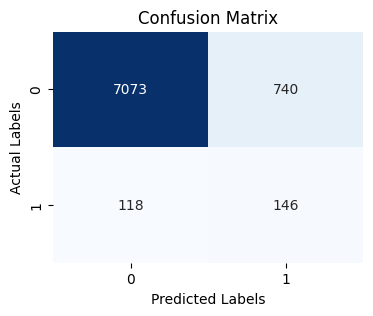

In [52]:
confusion = confusion_matrix(y_graph_test.reshape(-1), y_test_prediction)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

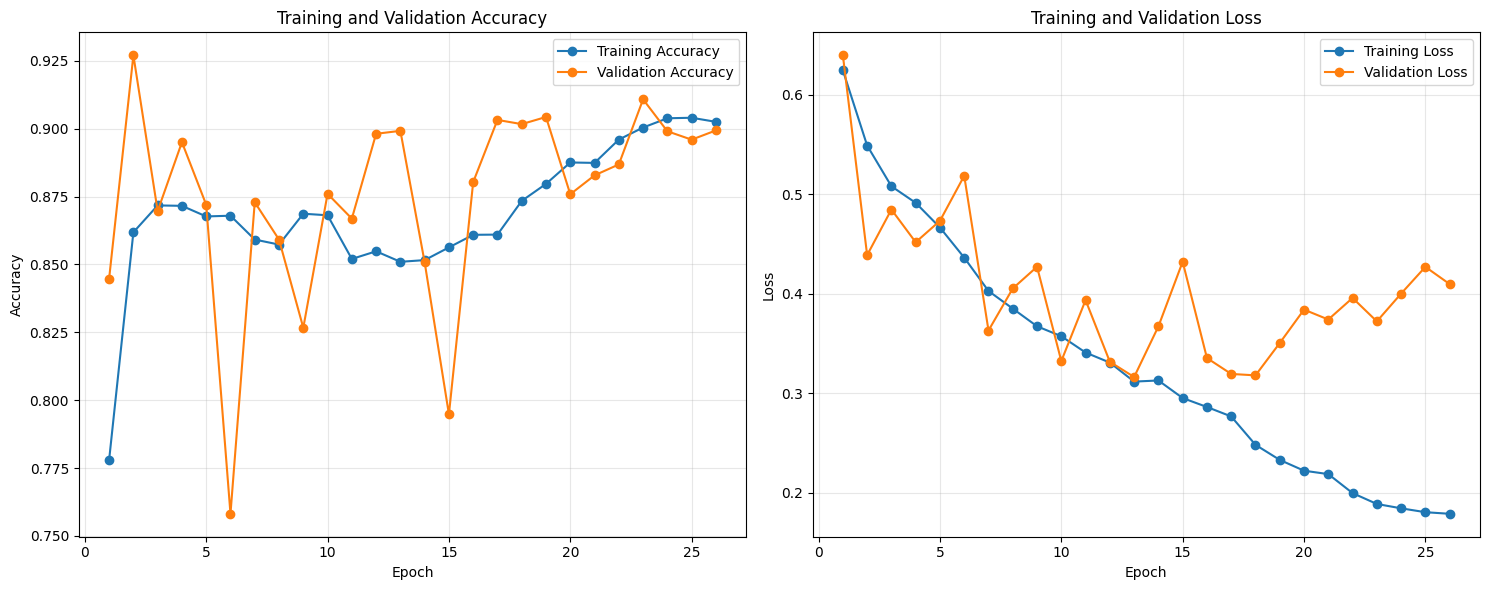

In [53]:
# Jumlah epoch yang benar-benar dijalankan
epochs_range = range(1, len(history.history["loss"]) + 1)

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)


# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### AUC Curve

ROC-AUC: 0.7828192329024276
PR-AUC: 0.3285496383135546


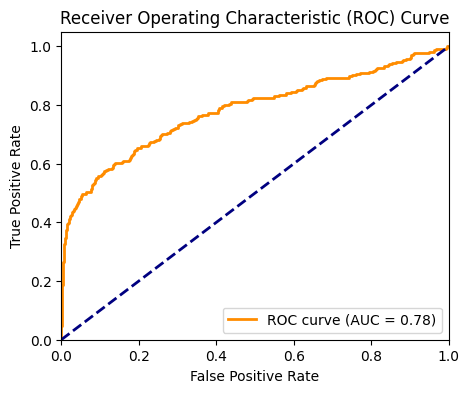

In [54]:
print("ROC-AUC:", roc_auc_score(y_graph_test.reshape(-1), y_test_probability))
print("PR-AUC:", average_precision_score(y_graph_test.reshape(-1), y_test_probability))

# ROC Curve
fpr, tpr, _ = roc_curve(y_graph_test.reshape(-1), y_test_probability)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### c) Save & Load Model

In [ ]:
# SAVE MODEL
model_gcn_gat.save("model/gcn_gat_model.keras")

In [ ]:
loaded_model_gcn_gat = tf.keras.models.load_model(
    "model/gcn_gat_model.keras",
    custom_objects={
        "GCNConv":GCNConv,
        "GATConv":GATConv,
        "MaskedGlobalAveragePooling":MaskedGlobalAveragePooling,
        "MolecularGCNGAT>MaskedGlobalAveragePooling":MaskedGlobalAveragePooling
    },
    compile=False
)

c:\Users\ASUS\anaconda3\envs\hiv_env\Lib\site-packages\tf_keras\src\initializers\initializers.py:121: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [ ]:
# APPLY LOADED MODEL TO TEST DATA (or any data)
y_test_probability = loaded_model_gcn_gat.predict([X_graph_test, A_graph_test, A_gat_test, M_graph_test], batch_size=32).reshape(-1)
y_test_prediction = (y_test_probability >= 0.5).astype(int)

print("Probabilitas 10 data pertama:")
print(y_test_probability[:10])

print("Prediksi kelas 10 data pertama:")
print(y_test_prediction[:10])

253/253 [==============================] - 16s 57ms/step
Probabilitas 10 data pertama:
[9.3047591e-03 8.9314173e-04 2.6328176e-01 4.4171050e-02 6.6798786e-04
 6.8235196e-02 6.9521123e-01 9.6865517e-01 6.1130333e-01 8.4172487e-03]
Prediksi kelas 10 data pertama:
[0 0 0 0 0 0 1 1 1 0]


# Past & Current Performances (Best to Worst)

NO RANDOM OVERSAMPLING, USING CLASS WEIGHTING (negative = 0.517, positive = 15.31), `early stopping = val_pr_auc` ***[CURRENT]***
| Model         |   Accuracy |   ROC-AUC |      PR-AUC | Precision + | Recall + |      F1 + |
| ------------- | ---------: | --------: | ----------: | ----------: | -------: | --------: |
| **GCN**       |     87.24% |     0.789 |       0.299 |       0.147 |    0.602 |     0.236 |
| **GAT**       |     88.18% |     0.797 |       0.298 |       0.144 |    0.530 |     0.227 |
| **GCN + GAT** |     89.38% |     0.783 |       0.329 |       0.165 |    0.553 |     0.254 |

NO RANDOM OVERSAMPLING, USING CLASS WEIGHTING (negative = 0.517, positive = 15.31), `early stopping = val_auc`
| Model         |   Accuracy |   ROC-AUC |      PR-AUC | Precision + | Recall + |      F1 + |
| ------------- | ---------: | --------: | ----------: | ----------: | -------: | --------: |
| **GCN**       |     84.81% |     0.795 |       0.305 |       0.131 |    0.644 |     0.217 |
| **GAT**       |     86.64% |     0.783 |       0.281 |       0.131 |    0.549 |     0.212 |
| **GCN + GAT** |     89.72% |     0.782 |       0.330 |       0.167 |    0.538 |     0.255 |

USING RANDOM OVERSAMPLING, `early stopping = val_pr_auc`
| Model         |   Accuracy |   ROC-AUC |      PR-AUC | Precision + | Recall + |      F1 + |
| ------------- | ---------: | --------: | ----------: | ----------: | -------: | --------: |
| **GCN**       |     91.17% |     0.794 |       0.309 |       0.199 |    0.561 |     0.293 |
| **GAT**       |     92.63% |     0.769 |       0.318 |       0.218 |    0.485 |     0.301 |
| **GCN + GAT** |     95.13% |     0.790 |       0.263 |       0.327 |    0.462 |     0.383 |

USING RANDOM OVERSAMPLING, `early stopping = val_auc`
| Model         |   Accuracy |   ROC-AUC |      PR-AUC | Precision + | Recall + |      F1 + |
| ------------- | ---------: | --------: | ----------: | ----------: | -------: | --------: |
| **GCN**       |     88.56% |     0.800 |       0.322 |       0.160 |    0.587 |     0.251 |
| **GAT**       |     92.45% |     0.759 |       0.280 |       0.212 |    0.481 |     0.294 |
| **GCN + GAT** |     90.96% |     0.791 |       0.254 |       0.193 |    0.553 |     0.286 |

USINF RANDOM UNDERSAMPLING (1:5), CLASS 1 IS GIVEN WEIGHT (negative = 1, positive = 2.5), `early stopping = val_auc`
| Model         |   Accuracy |   ROC-AUC |      PR-AUC | Precision + | Recall + |      F1 + |
| ------------- | ---------: | --------: | ----------: | ----------: | -------: | --------: |
| **GCN**       |     87.57% |     0.787 |       0.274 |       0.142 |    0.553 |     0.225 |
| **GAT**       |     90.78% |     0.749 |       0.192 |       0.160 |    0.428 |     0.233 |
| **GCN + GAT** |     88.94% |     0.784 |       0.221 |       0.151 |    0.515 |     0.234 |